In [20]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file_path="train.csv/train.csv"

In [3]:
column_names = ['label'] + [f'pixel{i}' for i in range(784)]

dataset = tf.data.experimental.make_csv_dataset(
    file_path,
    batch_size=32,
    column_names=column_names,
    label_name='label',  # Specify the column to use as the label
    num_epochs=1,
    ignore_errors=True
)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [5]:
def preprocess(features, labels):
    features = tf.stack(list(features.values()), axis=1)
    features=tf.cast(features,tf.float32)
    features = tf.reshape(features, [-1, 28, 28, 1])/255.0
    return features, labels
dataset=dataset.map(preprocess)

In [9]:
print(dataset.element_spec)

(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


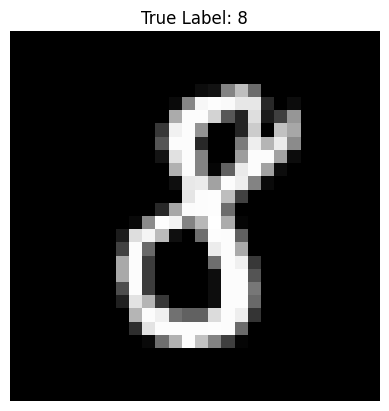

In [ ]:
for images, labels in dataset.take(1):     # from first batch 
    first_image = images[2].numpy()
    first_label = labels[2].numpy()

    # Squeeze the image to remove the channel dimension (from 28x28x1 to 28x28)
    # This is a common practice for displaying grayscale images with Matplotlib.
    first_image = np.squeeze(first_image, axis=-1)

    # Display the image using matplotlib
    plt.imshow(first_image, cmap='gray')
    
    # Add a title to show the predicted label
    plt.title(f'True Label: {first_label}')
    
    # Turn off the axis labels for a cleaner look
    plt.axis('off')
    
    # Show the plot
    plt.show()

In [16]:
DATASET_SIZE = 0
for _ in dataset:
    DATASET_SIZE += 1
print(f"Total batches found: {DATASET_SIZE}")
    
# Define the split ratio
TRAIN_RATIO = 0.8
test_ratio = 1 - TRAIN_RATIO

# Calculate the number of batches for each split
train_batches = int(DATASET_SIZE * TRAIN_RATIO)
test_batches = DATASET_SIZE - train_batches

print(f"Total Batches: {DATASET_SIZE}")
print(f"Training Batches: {train_batches}")
print(f"Test Batches: {test_batches}")

# Shuffle the entire dataset before splitting to ensure a random distribution
# A large buffer size ensures a good shuffle
SHUFFLE_SIZE = 1000
dataset = dataset.shuffle(SHUFFLE_SIZE)

# Split the dataset into train and test sets
train_dataset = dataset.take(train_batches)
test_dataset = dataset.skip(train_batches)
# .cache() keeps the data in memory after the first epoch,
# preventing the need to re-read the file.
# .prefetch() overlaps data preprocessing and model training.
train_dataset = train_dataset.cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(tf.data.AUTOTUNE)

Total batches found: 1313
Total Batches: 1313
Training Batches: 1050
Test Batches: 263


In [23]:
model=models.Sequential([
    layers.Input(shape=(28,28,1)),layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [24]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
model.fit(train_dataset,epochs=20)

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 110s 47ms/step - accuracy: 0.8470 - loss: 0.4992
Epoch 2/20


d:\Anaconda\envs\tf-env\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.9644 - loss: 0.1136
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.9770 - loss: 0.0729
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9817 - loss: 0.0524
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9856 - loss: 0.0415
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.9886 - loss: 0.0321
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9910 - loss: 0.0289
Epoch 8/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9921 - loss: 0.0258
Epoch 9/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step - accuracy: 0.9921 - loss: 0.0225
Epoch 10/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.9931 - loss: 0.0213
Epoch 11/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9956 - loss: 0.0140
Epoch 12/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9935 - loss: 0.0211
Epoch 13/20
1050/1

In [26]:
test_loss,test_accuracy=model.evaluate(test_dataset)
print(f"Test accuracy: {test_accuracy:.4f}")

263/263 ━━━━━━━━━━━━━━━━━━━━ 69s 4ms/step - accuracy: 0.9913 - loss: 0.0387
Test accuracy: 0.9901


d:\Anaconda\envs\tf-env\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
